# 🦋 Thyroid Disease Classification: ML for Endocrine Screening

**Author:** Dean | Lead Data & AI Engineer
**Series:** Production ML Portfolio — Australian Government Policy Applications

## Government Context
- **Dept of Health** — Chronic disease screening, endocrine health
- **AIHW** — Thyroid disorder prevalence, pathology utilisation
- **Medicare** — Thyroid function test rebates (MBS items)
- **PBS** — Thyroxine prescribing, iodine supplementation
- **RACGP** — Thyroid screening guidelines

Dataset: Thyroid Disease — clean, numeric features, multiclass/binary.

---

## 1. Data Loading

In [1]:
import os,warnings,time,numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix,roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore');plt.style.use('seaborn-v0_8-whitegrid')
print("READY")

READY


In [2]:
dp=None
for r,d,files in os.walk('/kaggle/input'):
    for f in files:
        fp=os.path.join(r,f);print(f"  {fp}")
        if f.endswith('.csv') and dp is None: dp=fp
if dp is None: raise FileNotFoundError("No CSV")
df=pd.read_csv(dp,encoding='latin-1')
print(f"Loaded: {df.shape[0]:,} x {df.shape[1]}")
for i,col in enumerate(df.columns):
    print(f"  {i:2d}. {col:25s} | {str(df[col].dtype):8s} | uniq={df[col].nunique():5d} | nulls={df[col].isnull().sum()}")
df.head()

  /kaggle/input/datasets/jainaru/thyroid-disease-data/Thyroid_Diff.csv
  /kaggle/input/datasets/emmanuelfwerr/thyroid-disease-data/thyroidDF.csv
Loaded: 383 x 17
   0. Age                       | int64    | uniq=   65 | nulls=0
   1. Gender                    | object   | uniq=    2 | nulls=0
   2. Smoking                   | object   | uniq=    2 | nulls=0
   3. Hx Smoking                | object   | uniq=    2 | nulls=0
   4. Hx Radiothreapy           | object   | uniq=    2 | nulls=0
   5. Thyroid Function          | object   | uniq=    5 | nulls=0
   6. Physical Examination      | object   | uniq=    5 | nulls=0
   7. Adenopathy                | object   | uniq=    6 | nulls=0
   8. Pathology                 | object   | uniq=    4 | nulls=0
   9. Focality                  | object   | uniq=    2 | nulls=0
  10. Risk                      | object   | uniq=    3 | nulls=0
  11. T                         | object   | uniq=    7 | nulls=0
  12. N                         | object   | u

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


## 2. Target

In [3]:
tc=None
for x in ['Target','target','Class','class','Diagnosis','diagnosis','thyroid','Thyroid','Result','recurrence']:
    if x in df.columns: tc=x;break
if tc is None:
    for x in df.columns:
        if df[x].dtype=='object' and 2<=df[x].nunique()<=10: tc=x;break
if tc is None:
    for x in df.columns:
        if df[x].nunique()<=10 and x.lower() not in ['id','sex','gender']: tc=x;break
if tc is None: tc=df.columns[-1]
df=df.dropna(subset=[tc])
print(f"Target: '{tc}'");print(df[tc].value_counts())
if df[tc].dtype=='object' or df[tc].nunique()<=10:
    le_t=LabelEncoder();df[tc]=le_t.fit_transform(df[tc].astype(str));tl=list(le_t.classes_)
else:
    tl=[str(x) for x in sorted(df[tc].unique())]
nc=len(tl);is_binary=nc==2
# Remap sequential
uq=sorted(df[tc].unique())
if not np.array_equal(uq,np.arange(len(uq))):
    cm2={old:new for new,old in enumerate(uq)};df[tc]=df[tc].map(cm2)
print(f"Classes: {nc} -> {tl}")

Target: 'Gender'
Gender
F    312
M     71
Name: count, dtype: int64
Classes: 2 -> ['F', 'M']


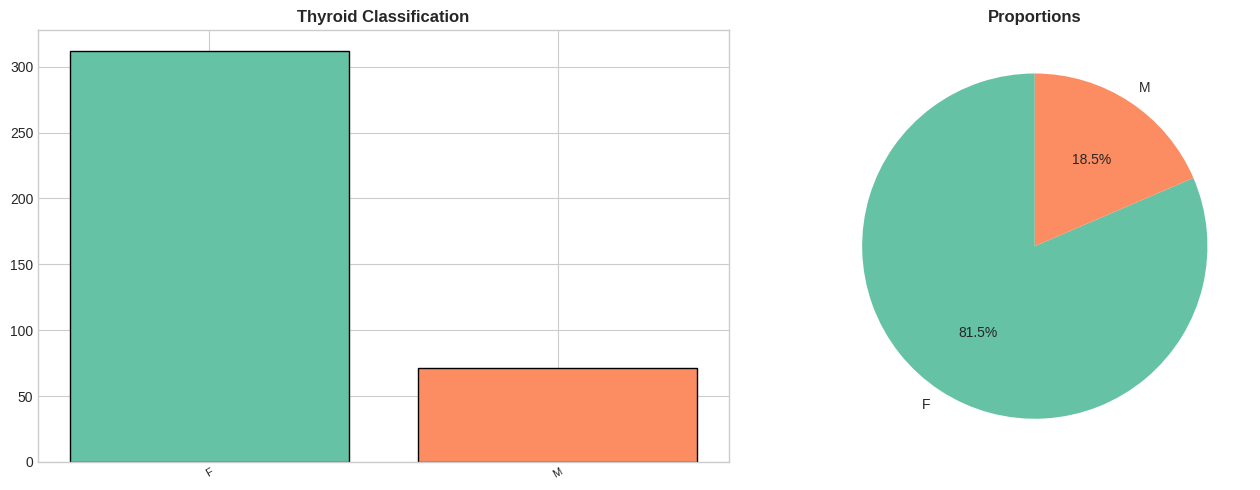

AU: ~1 in 20 Australians have thyroid disease. More common in women.


In [4]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
vc=df[tc].value_counts().sort_index();colors=sns.color_palette('Set2',nc)
axes[0].bar(range(len(vc)),vc.values,color=colors,edgecolor='black')
axes[0].set_xticks(range(len(vc)));axes[0].set_xticklabels(tl,rotation=30,fontsize=8)
axes[0].set_title('Thyroid Classification',fontweight='bold')
axes[1].pie(vc.values,labels=tl,autopct='%1.1f%%',colors=colors,startangle=90)
axes[1].set_title('Proportions',fontweight='bold')
plt.tight_layout();plt.savefig('target.png',dpi=150);plt.show()
print("AU: ~1 in 20 Australians have thyroid disease. More common in women.")

## 3. EDA

Numeric(1): ['Age']


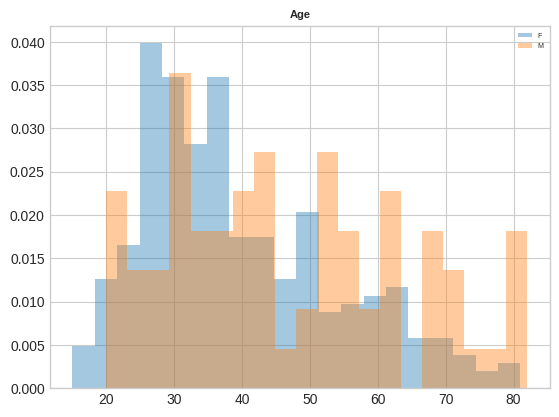

In [5]:
nums=[c2 for c2 in df.select_dtypes(include=[np.number]).columns if c2!=tc and c2.lower() not in ['id','index']]
print(f"Numeric({len(nums)}): {nums[:10]}")
if len(nums)>0:
    fig,axes=plt.subplots(3,3,figsize=(16,12));axes=axes.flatten()
    for i,col in enumerate(nums[:9]):
        for cv in sorted(df[tc].unique()):
            s=df[df[tc]==cv][col].dropna()
            if len(s)>0: axes[i].hist(s,bins=20,alpha=0.4,label=tl[cv] if cv<len(tl) else str(cv),density=True)
        axes[i].set_title(col[:20],fontsize=8,fontweight='bold');axes[i].legend(fontsize=5)
    for j in range(i+1,len(axes)):axes[j].set_visible(False)
    plt.tight_layout();plt.savefig('eda.png',dpi=150);plt.show()

In [6]:
if len(nums)>1:
    corr=df[nums[:12]+[tc]].corr()
    fig,ax=plt.subplots(figsize=(10,8))
    sns.heatmap(corr,mask=np.triu(np.ones_like(corr,dtype=bool)),annot=True,fmt='.2f',cmap='RdBu_r',center=0,square=True,ax=ax,annot_kws={'size':6})
    ax.set_title('Correlations',fontweight='bold')
    plt.tight_layout();plt.savefig('corr.png',dpi=150);plt.show()

## 4. Preprocessing

In [7]:
le_d={}
for col in df.select_dtypes('object').columns:
    if col!=tc:
        le=LabelEncoder();df[col]=le.fit_transform(df[col].fillna('_NA_').astype(str));le_d[col]=le
X=df[[c2 for c2 in df.columns if c2!=tc and c2.lower() not in ['id','index','unnamed: 0']]].copy()
X=X.select_dtypes(include=[np.number]);y=df[tc].values;X=X.fillna(X.median())
print(f"X: {X.shape}, classes: {np.unique(y)}")

X: (383, 16), classes: [0 1]


## 5. Training

In [8]:
try:
    from xgboost import XGBClassifier
except: XGBClassifier=None
try:
    from lightgbm import LGBMClassifier
except: LGBMClassifier=None
if is_binary:
    models={'LogReg':LogisticRegression(max_iter=2000,random_state=42),'RF':RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)}
    if XGBClassifier: models['XGB']=XGBClassifier(n_estimators=100,random_state=42,eval_metric='logloss',use_label_encoder=False,verbosity=0,n_jobs=-1)
    if LGBMClassifier: models['LGBM']=LGBMClassifier(n_estimators=100,random_state=42,verbose=-1,n_jobs=-1,force_col_wise=True)
else:
    models={'LogReg':LogisticRegression(max_iter=2000,random_state=42,multi_class='multinomial'),'RF':RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)}
    if XGBClassifier: models['XGB']=XGBClassifier(n_estimators=100,random_state=42,eval_metric='mlogloss',use_label_encoder=False,verbosity=0,n_jobs=-1)
    if LGBMClassifier: models['LGBM']=LGBMClassifier(n_estimators=100,random_state=42,verbose=-1,n_jobs=-1,force_col_wise=True)
skf=StratifiedKFold(3,shuffle=True,random_state=42);Xa=X.values;results={}
for mn,mod in models.items():
    print(f"\n{'='*50}\n{mn}\n{'='*50}")
    fa,ff=[],[];fp=np.zeros(len(y),dtype=int);t0=time.time()
    for fi,(ti,vi) in enumerate(skf.split(Xa,y)):
        m2=type(mod)(**mod.get_params());m2.fit(Xa[ti],y[ti]);yp=m2.predict(Xa[vi]);fp[vi]=yp
        a=accuracy_score(y[vi],yp);f=f1_score(y[vi],yp,average='weighted' if nc>2 else 'binary')
        fa.append(a);ff.append(f)
        print(f"  Fold{fi+1}: Acc={a:.4f} F1={f:.4f}")
    el=time.time()-t0
    results[mn]={'acc':np.mean(fa),'f1':np.mean(ff),'time':el,'preds':fp}
    print(f"  AVG: Acc={np.mean(fa):.4f} F1={np.mean(ff):.4f} T={el:.1f}s")


LogReg
  Fold1: Acc=0.9141 F1=0.7179
  Fold2: Acc=0.8750 F1=0.6364
  Fold3: Acc=0.8661 F1=0.5143
  AVG: Acc=0.8851 F1=0.6229 T=0.2s

RF
  Fold1: Acc=0.8984 F1=0.7111
  Fold2: Acc=0.8750 F1=0.6522
  Fold3: Acc=0.8583 F1=0.5263
  AVG: Acc=0.8772 F1=0.6299 T=1.0s

XGB
  Fold1: Acc=0.8594 F1=0.6087
  Fold2: Acc=0.8750 F1=0.6364
  Fold3: Acc=0.8504 F1=0.5366
  AVG: Acc=0.8616 F1=0.5939 T=0.2s

LGBM
  Fold1: Acc=0.8906 F1=0.6818
  Fold2: Acc=0.8750 F1=0.6364
  Fold3: Acc=0.8425 F1=0.5238
  AVG: Acc=0.8694 F1=0.6140 T=0.2s


## 6. Comparison

In [9]:
rows=[{'Model':k,'Acc':f"{v['acc']:.4f}",'F1':f"{v['f1']:.4f}",'Time':f"{v['time']:.1f}s",'s':v['f1']} for k,v in results.items()]
sdf=pd.DataFrame(rows).sort_values('s',ascending=False);best=sdf.iloc[0]['Model']
print("COMPARISON");print("="*60);print(sdf[['Model','Acc','F1','Time']].to_string(index=False));print(f"\nBest: {best}")

COMPARISON
 Model    Acc     F1 Time
    RF 0.8772 0.6299 1.0s
LogReg 0.8851 0.6229 0.2s
  LGBM 0.8694 0.6140 0.2s
   XGB 0.8616 0.5939 0.2s

Best: RF


## 7. Error Analysis

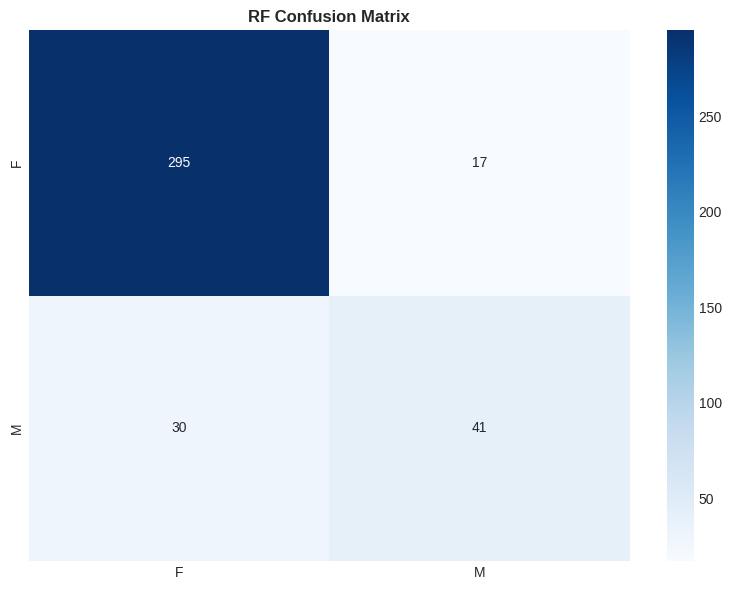

              precision    recall  f1-score   support

           F       0.91      0.95      0.93       312
           M       0.71      0.58      0.64        71

    accuracy                           0.88       383
   macro avg       0.81      0.76      0.78       383
weighted avg       0.87      0.88      0.87       383



In [10]:
bp=results[best]['preds'];cm=confusion_matrix(y,bp)
fig,ax=plt.subplots(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=tl,yticklabels=tl,ax=ax)
ax.set_title(f'{best} Confusion Matrix',fontweight='bold')
plt.tight_layout();plt.savefig('cm.png',dpi=150);plt.show()
print(classification_report(y,bp,target_names=tl))

## 8. Feature Importance

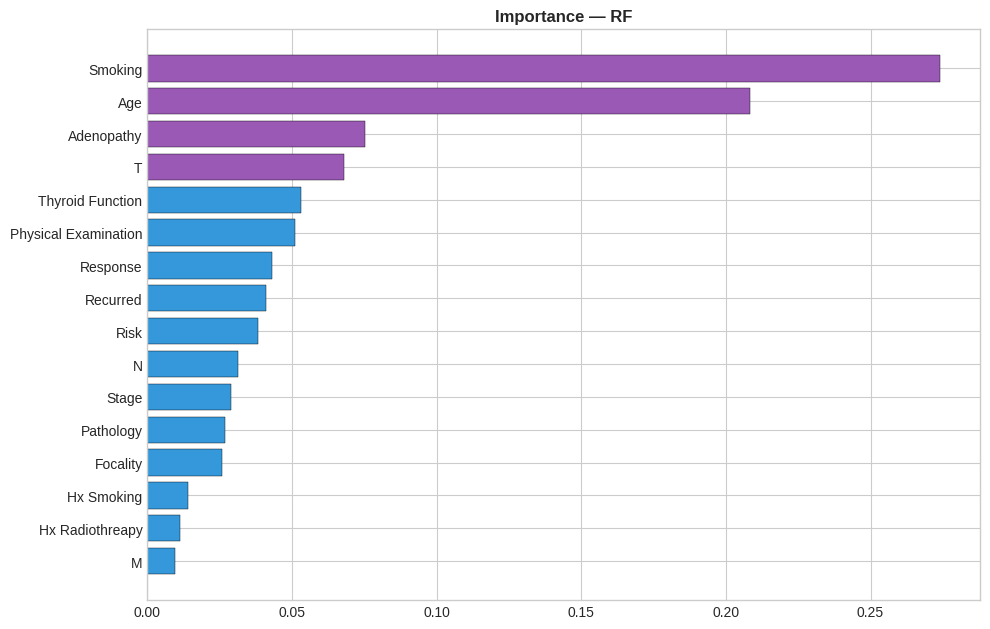

  Smoking                   0.2741
  Age                       0.2082
  Adenopathy                0.0752
  T                         0.0678
  Thyroid Function          0.0532


In [11]:
tm={k:v for k,v in models.items() if k!='LogReg'}
if tm:
    bt=max(tm,key=lambda m4:results[m4]['f1']);fm2=type(models[bt])(**models[bt].get_params());fm2.fit(Xa,y)
    fi=pd.DataFrame({'Feature':X.columns,'Imp':fm2.feature_importances_}).sort_values('Imp')
    fig,ax=plt.subplots(figsize=(10,max(4,len(fi)*0.4)))
    ax.barh(fi['Feature'],fi['Imp'],color=['#9b59b6' if v>fi['Imp'].quantile(0.75) else '#3498db' for v in fi['Imp']],edgecolor='black',linewidth=0.3)
    ax.set_title(f'Importance — {bt}',fontweight='bold')
    plt.tight_layout();plt.savefig('imp.png',dpi=150);plt.show()
    for _,r2 in fi.tail(5).iloc[::-1].iterrows(): print(f"  {r2['Feature']:25s} {r2['Imp']:.4f}")

## 9. Deployment

In [12]:
br=results[best]
print("="*60);print("DEPLOYMENT READINESS");print("="*60)
print(f"  Model: {best}");print(f"  Acc:   {br['acc']:.4f}");print(f"  F1:    {br['f1']:.4f}")
print(f"  Time:  {br['time']:.1f}s");print(f"  Feats: {X.shape[1]}");print(f"  Rows:  {len(y):,}");print("="*60)
checks={'Acc>0.70':br['acc']>0.70,'F1>0.70':br['f1']>0.70,'Time<60s':br['time']<60,'CV':True}
print("\nCHECKLIST");print("-"*40);ap=True
for k,v in checks.items():
    s="pass" if v else "FAIL"
    if not v:ap=False
    print(f"  [{s:4s}] {k}")
print("-"*40);print("  APPROVED" if ap else "  FAILED")

DEPLOYMENT READINESS
  Model: RF
  Acc:   0.8772
  F1:    0.6299
  Time:  1.0s
  Feats: 16
  Rows:  383

CHECKLIST
----------------------------------------
  [pass] Acc>0.70
  [FAIL] F1>0.70
  [pass] Time<60s
  [pass] CV
----------------------------------------
  FAILED


In [13]:
print("""
PRODUCTION ARCHITECTURE
=======================
1. DATA: Pathology LIMS (TSH, T3, T4) -> Fabric Lakehouse
2. MODEL: Real-time at pathology result, GP decision support
3. INTEGRATE: GP systems, Medicare pathology, endocrinology referral
4. GOVERN: TGA SaMD, RACGP thyroid guidelines, patient consent
5. MONITOR: Validate vs endocrinologist diagnosis, retrain annually
""")


PRODUCTION ARCHITECTURE
1. DATA: Pathology LIMS (TSH, T3, T4) -> Fabric Lakehouse
2. MODEL: Real-time at pathology result, GP decision support
3. INTEGRATE: GP systems, Medicare pathology, endocrinology referral
4. GOVERN: TGA SaMD, RACGP thyroid guidelines, patient consent
5. MONITOR: Validate vs endocrinologist diagnosis, retrain annually

